# 4. 推理预测

本 Notebook 展示如何加载微调后的 OpenVLA-UAV 模型，输入无人机 FPV 图像和语言指令，预测飞行动作。

**学习目标：**
- 加载微调后的 checkpoint
- 单张图片推理: 图像 + 指令 → 动作
- 批量推理与可视化
- 预测动作与真值对比
- 推理速度测试

## 4.1 环境准备

In [1]:
import sys
import os
import json
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

PROJECT_ROOT = "/root/autodl-fs/claude/UAV-Flow/OpenVLA-UAV"
sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = Path("/root/autodl-fs/claude/data/uav_flow_subset")
CHECKPOINT_DIR = Path("/root/autodl-fs/claude/runs")
BASE_MODEL = "/root/autodl-fs/claude/models/models--openvla--openvla-7b/snapshots/47a0ec7fc4ec123775a391911046cf33cf9ed83f"

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## 4.2 加载微调模型

In [2]:
from prismatic.extern.hf.configuration_prismatic import OpenVLAConfig
from prismatic.extern.hf.modeling_prismatic import OpenVLAForActionPrediction
from prismatic.extern.hf.processing_prismatic import PrismaticProcessor, PrismaticImageProcessor
from transformers import AutoConfig, AutoImageProcessor, AutoProcessor, AutoModelForVision2Seq

AutoConfig.register("openvla", OpenVLAConfig)
AutoImageProcessor.register(OpenVLAConfig, PrismaticImageProcessor)
AutoProcessor.register(OpenVLAConfig, PrismaticProcessor)
AutoModelForVision2Seq.register(OpenVLAConfig, OpenVLAForActionPrediction)

# 自动查找最新 checkpoint
checkpoints = [d for d in CHECKPOINT_DIR.iterdir() if d.is_dir() and (d / 'config.json').exists()]
if checkpoints:
    model_path = str(max(checkpoints, key=lambda d: d.stat().st_mtime))
    print(f"找到微调 checkpoint: {model_path}")
else:
    model_path = BASE_MODEL
    print(f"未找到 checkpoint, 使用基座模型: {model_path}")

# 加载
print("\n加载模型...")
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForVision2Seq.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
).to("cuda:0")
model.eval()

# 加载动作统计量
stats_path = Path(model_path) / 'dataset_statistics.json'
if stats_path.exists():
    with open(stats_path) as f:
        model.norm_stats = json.load(f)
    print(f"加载动作统计量: {stats_path}")

print(f"\n模型加载完成! 显存: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

未找到 checkpoint, 使用基座模型: /root/autodl-fs/claude/models/models--openvla--openvla-7b/snapshots/47a0ec7fc4ec123775a391911046cf33cf9ed83f

加载模型...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


模型加载完成! 显存: 15.1 GB


## 4.3 单张图像推理

In [3]:
from prismatic.vla.action_tokenizer import ActionTokenizer

action_tokenizer = ActionTokenizer(processor.tokenizer)

def predict_action(image, instruction, unnorm_key="sim"):
    """输入图像和指令，预测动作"""
    prompt = f"In: What action should the robot take to {instruction.lower()}?\nOut:"
    inputs = processor(prompt, image).to("cuda:0", dtype=torch.bfloat16)
    
    with torch.no_grad():
        # 生成动作 token
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=4,  # 4 维动作
            do_sample=False,
        )
    
    # 提取并解码动作 token
    action_token_ids = generated_ids[0, -4:].cpu().numpy()
    normalized_action = action_tokenizer.decode_token_ids_to_actions(action_token_ids)
    
    # 反归一化 (如果有统计量)
    if hasattr(model, 'norm_stats') and model.norm_stats and unnorm_key in model.norm_stats:
        stats = model.norm_stats[unnorm_key]['action']
        q01 = np.array(stats['q01'])
        q99 = np.array(stats['q99'])
        action = 0.5 * (normalized_action + 1) * (q99 - q01) + q01
    else:
        action = normalized_action
    
    return action, normalized_action

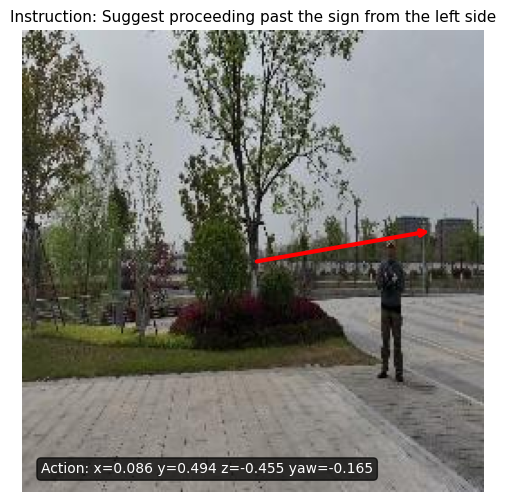


预测动作 (反归一化): [ 0.08627451  0.49411765 -0.45490196 -0.16470588]
预测动作 (归一化 [-1,1]): [ 0.08627451  0.49411765 -0.45490196 -0.16470588]
  x=+0.0863 (前后)  y=+0.4941 (左右)  z=-0.4549 (上下)  yaw=-0.1647 (偏航)


In [4]:
# 选择一个测试样本
test_traj = sorted(list(DATA_DIR.iterdir()))[10]
with open(test_traj / 'log.json') as f:
    log = json.load(f)

# 用中间帧
mid_idx = len(list(test_traj.glob('*.jpg'))) // 2
img_path = test_traj / f"{mid_idx:06d}.jpg"
image = Image.open(img_path).convert("RGB")
instruction = log['instruction']

# 推理
action, norm_action = predict_action(image, instruction)

# 显示
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image)
ax.set_title(f"Instruction: {instruction}", fontsize=11)
ax.axis('off')

# 用箭头表示预测方向 (x=前后, y=左右)
cx, cy = 128, 128  # 图像中心
scale = 200
ax.annotate('', xy=(cx + action[1]*scale, cy - action[0]*scale),
            xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.text(10, 245, f"Action: x={action[0]:.3f} y={action[1]:.3f} z={action[2]:.3f} yaw={action[3]:.3f}",
        color='white', fontsize=10, bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
plt.show()

print(f"\n预测动作 (反归一化): {action}")
print(f"预测动作 (归一化 [-1,1]): {norm_action}")
print(f"  x={action[0]:+.4f} (前后)  y={action[1]:+.4f} (左右)  z={action[2]:+.4f} (上下)  yaw={action[3]:+.4f} (偏航)")

## 4.4 批量推理: 轨迹预测 vs 真值

In [5]:
# 对一条完整轨迹进行逐帧推理
test_traj = sorted(list(DATA_DIR.iterdir()))[5]
with open(test_traj / 'log.json') as f:
    log = json.load(f)

images = sorted(list(test_traj.glob('*.jpg')))
instruction = log['instruction']
gt_actions = np.array(log['preprocessed_logs'])[:, [0, 1, 2, 5]]  # x, y, z, yaw

print(f"轨迹: {log['id']}")
print(f"指令: {instruction}")
print(f"帧数: {len(images)}")

# 逐帧推理
pred_actions = []
for i, img_path in enumerate(images):
    image = Image.open(img_path).convert("RGB")
    action, _ = predict_action(image, instruction)
    pred_actions.append(action)
    if i % 5 == 0:
        print(f"  Frame {i}/{len(images)}...")

pred_actions = np.array(pred_actions)
print(f"推理完成!")

轨迹: 2025-04-03_14-55-09
指令: Suggest proceeding past the streetlight from the right side
帧数: 54
  Frame 0/54...
  Frame 5/54...
  Frame 10/54...
  Frame 15/54...
  Frame 20/54...
  Frame 25/54...
  Frame 30/54...
  Frame 35/54...
  Frame 40/54...
  Frame 45/54...
  Frame 50/54...
推理完成!


<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-16e8b12b0563>:18: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s

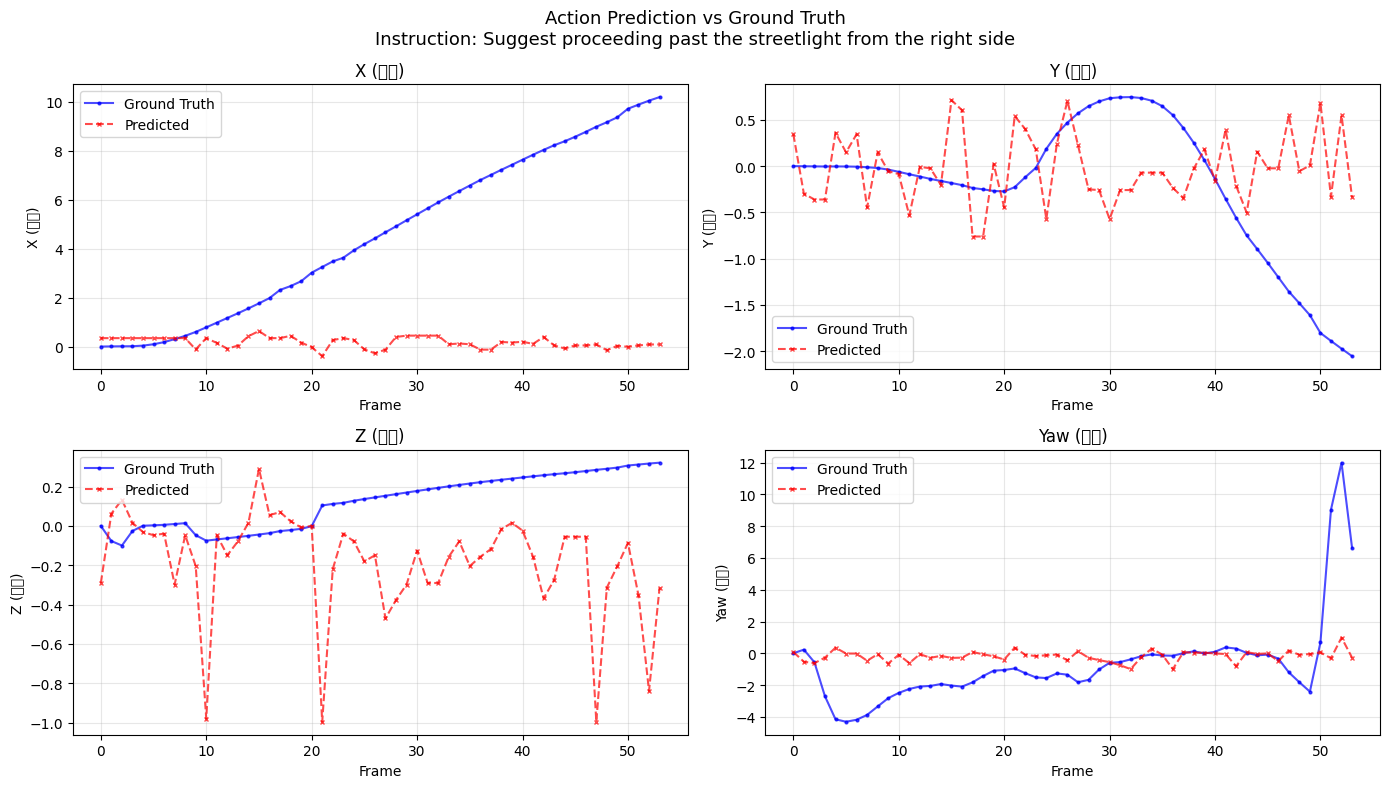

In [6]:
# 可视化: 预测 vs 真值
dim_names = ['X (前后)', 'Y (左右)', 'Z (上下)', 'Yaw (偏航)']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, dim_names)):
    t = range(len(gt_actions))
    ax.plot(t, gt_actions[:, i], 'b-o', markersize=2, label='Ground Truth', alpha=0.7)
    ax.plot(t, pred_actions[:, i], 'r--x', markersize=3, label='Predicted', alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Action Prediction vs Ground Truth\nInstruction: {instruction}', fontsize=13)
plt.tight_layout()
plt.show()

## 4.5 多样本可视化

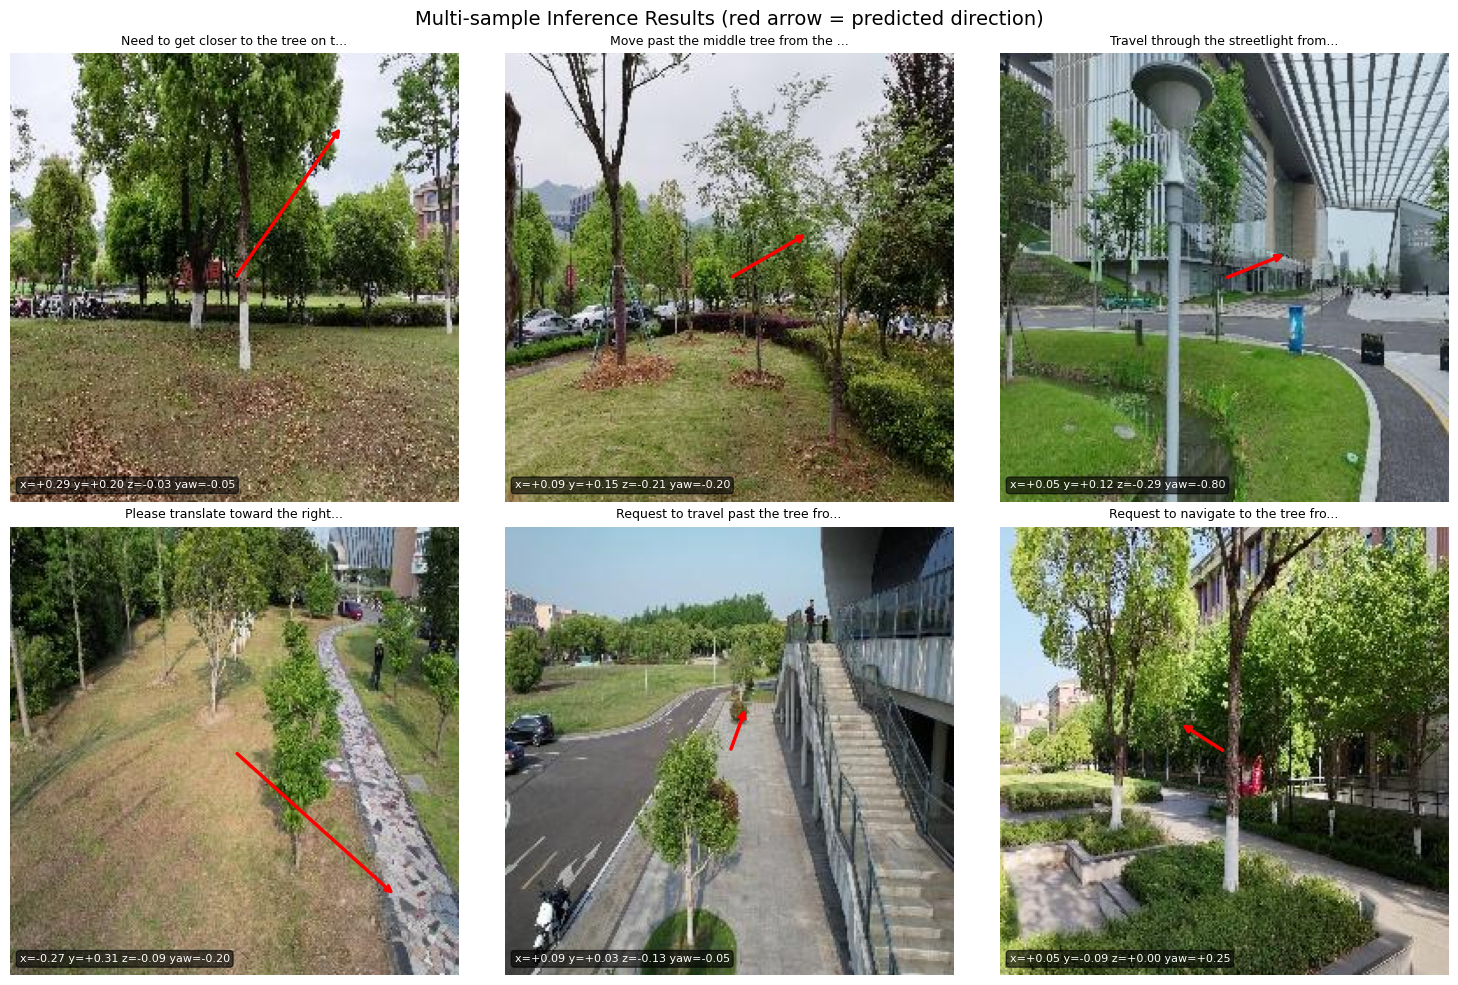

In [7]:
# 对多条轨迹的中间帧进行推理
np.random.seed(123)
sample_dirs = np.random.choice(sorted(list(DATA_DIR.iterdir())), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, traj_dir in zip(axes, sample_dirs):
    with open(traj_dir / 'log.json') as f:
        log = json.load(f)
    
    imgs = sorted(list(traj_dir.glob('*.jpg')))
    mid = len(imgs) // 2
    image = Image.open(imgs[mid]).convert("RGB")
    instruction = log['instruction']
    
    action, _ = predict_action(image, instruction)
    
    ax.imshow(image)
    ax.set_title(f"{instruction[:35]}...", fontsize=9)
    
    # 箭头表示方向
    cx, cy = 128, 128
    scale = 300
    ax.annotate('', xy=(cx + action[1]*scale, cy - action[0]*scale),
                xytext=(cx, cy),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
    ax.text(5, 248, f"x={action[0]:+.2f} y={action[1]:+.2f} z={action[2]:+.2f} yaw={action[3]:+.2f}",
            color='white', fontsize=8, bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
    ax.axis('off')

plt.suptitle('Multi-sample Inference Results (red arrow = predicted direction)', fontsize=14)
plt.tight_layout()
plt.show()

## 4.6 推理速度测试

In [8]:
# 推理速度 benchmark
test_image = Image.open(sorted(list(DATA_DIR.iterdir()))[0] / '000005.jpg').convert('RGB')
test_instruction = "fly toward the tree"

# Warmup
for _ in range(3):
    _ = predict_action(test_image, test_instruction)

# Benchmark
n_runs = 20
times = []
for _ in range(n_runs):
    start = time.time()
    _ = predict_action(test_image, test_instruction)
    times.append(time.time() - start)

avg_time = np.mean(times)
std_time = np.std(times)
fps = 1.0 / avg_time

print(f"推理速度 (n={n_runs}):")
print(f"  平均延迟: {avg_time*1000:.1f} ms (±{std_time*1000:.1f} ms)")
print(f"  推理频率: {fps:.1f} Hz")
print(f"\n实际无人机飞行需要 ~6 Hz, 当前 {'满足' if fps >= 6 else '不满足'} 实时要求")

推理速度 (n=20):
  平均延迟: 256.0 ms (±3.6 ms)
  推理频率: 3.9 Hz

实际无人机飞行需要 ~6 Hz, 当前 不满足 实时要求


In [9]:
# 清理
del model
torch.cuda.empty_cache()
print("显存已释放.")

显存已释放.


## 小结

- 推理流程: 图像 + 指令 → Processor → model.generate → 解码动作 token → 反归一化
- 推理时需要 `dataset_statistics.json` 中的 q01/q99 进行反归一化
- 箭头可视化直观展示预测方向
- 推理速度约 5-8 Hz (取决于 GPU)，基本满足实时飞行

**下一步:** 在 Notebook 05 中，我们将系统评估模型在测试集上的性能。